# Optional pyabc comparison: continuous and mixed priors

 This notebook is an exploratory comparison, not the correctness oracle. Both
 samplers use 128 particles and the same explicit three-generation epsilon list.
 Histograms use posterior weights. Numerical / finite-epsilon correctness is tested
 independently in `tests/test_abc_statistical.py`.

 Install optional `pyabc` and run from `validation/`. Models are importable for
 epydemix's spawn workers and consume the passed Generator. pyabc's serial adapter
 owns a persistent Generator; its proposal RNG uses pyabc's global NumPy interface,
 seeded separately. Identical draws across libraries are not expected. A temporary
 SQLite directory is cleaned after each run. Measured with pyabc 0.13.0.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

In [2]:
import multiprocessing as mp
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pyabc
from scipy import stats

from epydemix.calibration import ABCSampler
from validation.toy_models import (
    absolute_distance,
    mixed_location_scale,
    normal_mean,
    squared_distance,
)

mp.set_start_method("spawn", force=True)
PARTICLES, WORKERS = 128, 2
print("pyabc", pyabc.__version__, "NumPy", np.__version__)

pyabc 0.13.0 NumPy 1.26.4


In [3]:
def compare(
    model, distance, epydemix_prior, pyabc_prior, observation, schedule, transition=None
):
    """Use identical statistical targets, with explicit RNG ownership per library."""
    np.random.seed(43)  # pyabc proposals use the legacy NumPy interface.
    simulation_rng = np.random.default_rng(44)

    def pyabc_model(parameters):
        return model(dict(parameters, rng=simulation_rng))

    abc = pyabc.ABCSMC(
        pyabc_model,
        pyabc_prior,
        lambda simulation, observed: distance(observed, simulation),
        population_size=PARTICLES,
        eps=pyabc.ListEpsilon(schedule),
        sampler=pyabc.sampler.SingleCoreSampler(),
        transitions=transition,
    )
    with tempfile.TemporaryDirectory(prefix="epydemix-pyabc-") as directory:
        abc.new(
            "sqlite:///" + str(Path(directory) / "comparison.db"), {"data": observation}
        )
        history = abc.run(
            max_nr_populations=len(schedule), minimum_epsilon=schedule[-1] / 2
        )
        py_posterior, py_weights = history.get_distribution(t=history.max_t)
        assert history.max_t == len(schedule) - 1
    sampler = ABCSampler(model, epydemix_prior, {}, observation, distance, rng=43)
    results = sampler.calibrate(
        strategy="smc",
        num_particles=PARTICLES,
        num_generations=len(schedule),
        epsilon_schedule=schedule,
        n_workers=WORKERS,
        verbose=False,
    )
    epi_posterior, epi_weights = (
        results.get_posterior_distribution(),
        results.get_weights(),
    )
    assert np.isclose(np.sum(py_weights), 1) and np.isclose(np.sum(epi_weights), 1)
    print(
        "epsilon",
        schedule,
        "epydemix simulations",
        results.calibration_params["execution_metrics"]["totals"]["simulations"],
    )
    for parameter in epydemix_prior:
        fig, ax = plt.subplots(figsize=(7, 3))
        bins = np.arange(-0.5, 7.5, 1) if parameter == "p_discrete" else 20
        ax.hist(
            py_posterior[parameter],
            weights=py_weights,
            bins=bins,
            alpha=0.5,
            label="pyabc",
        )
        ax.hist(
            epi_posterior[parameter],
            weights=epi_weights,
            bins=bins,
            alpha=0.5,
            label="epydemix",
        )
        ax.set(xlabel=parameter, ylabel="posterior mass")
        ax.legend()
        plt.show()
        plt.close(fig)

## Continuous mean model

 `mu ~ Uniform(0,5)`, `Y ~ Normal(mu,0.5)`, observed `2.5`, absolute distance.
 Compare weighted final-generation distributions at epsilon 0.25.


ABC.History INFO: Start <ABCSMC id=1, start_time=2026-09-30 06:59:58>


ABC INFO: t: 0, eps: 1.00000000e+00.


ABC INFO: Accepted: 128 / 318 = 4.0252e-01, ESS: 1.2800e+02.


ABC INFO: Timing t=0 [s]: total=0.145, simulation=0.0794 (55%), pipeline-setup=0.00302, prepare-next=0.0193 (population-size=0.00877, distance=0.00173).


ABC INFO: t: 1, eps: 5.00000000e-01.


...

ABC INFO: Accepted: 128 / 524 = 2.4427e-01, ESS: 1.1817e+02.


ABC INFO: Timing t=2 [s]: total=0.317, simulation=0.247 (78%), pipeline-setup=0.00275, prepare-next=0.0213 (population-size=0.0102, distance=0.00211).


ABC INFO: Stop: Maximum number of generations.


ABC.History INFO: Done <ABCSMC id=1, duration=0:00:00.816408, end_time=2026-09-30 06:59:59>


epsilon [1.0, 0.5, 0.25] epydemix simulations 1580


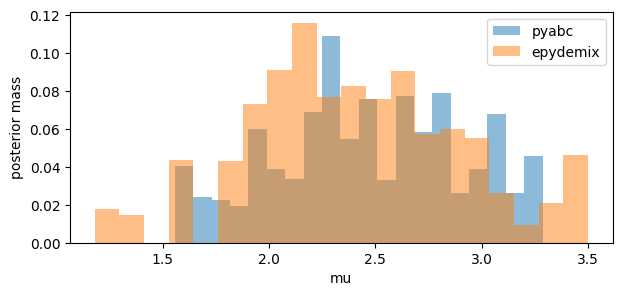

In [4]:
compare(
    normal_mean,
    absolute_distance,
    {"mu": stats.uniform(0, 5)},
    pyabc.Distribution(mu=pyabc.RV("uniform", 0, 5)),
    np.array([2.5]),
    [1.0, 0.5, 0.25],
)

## Mixed location / scale model

 `k` is uniform on 0..6, `s ~ Uniform(0,2)`. Eight observations are
 `k + J + s*Normal(0,1)` with one shared `J in {-2,0,2}` of probabilities
 `(0.2,0.5,0.3)`. Fixed observations use seed 47 at `(k,s)=(2,0.5)`.
 The squared-distance schedule is `[40,25,15]`. A discrete jump transition
 and continuous normal transition prevent treating an integer prior as continuous.


ABC.History INFO: Start <ABCSMC id=1, start_time=2026-09-30 07:00:06>


ABC INFO: t: 0, eps: 4.00000000e+01.


ABC INFO: Accepted: 128 / 262 = 4.8855e-01, ESS: 1.2800e+02.


ABC INFO: Timing t=0 [s]: total=0.485, simulation=0.231 (48%), pipeline-setup=0.00324, prepare-next=0.0399 (population-size=0.0193, distance=0.00469).


ABC INFO: t: 1, eps: 2.50000000e+01.


...

ABC INFO: Accepted: 128 / 499 = 2.5651e-01, ESS: 9.6559e+01.


ABC INFO: Timing t=2 [s]: total=0.731, simulation=0.635 (87%), pipeline-setup=0.00363, prepare-next=0.0237 (population-size=0.0109, distance=0.00191).


ABC INFO: Stop: Maximum number of generations.


ABC.History INFO: Done <ABCSMC id=1, duration=0:00:01.702054, end_time=2026-09-30 07:00:08>


epsilon [40.0, 25.0, 15.0] epydemix simulations 987


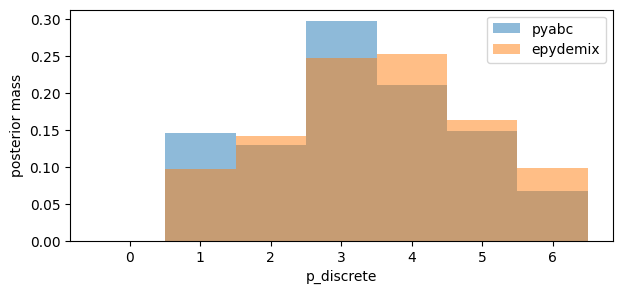

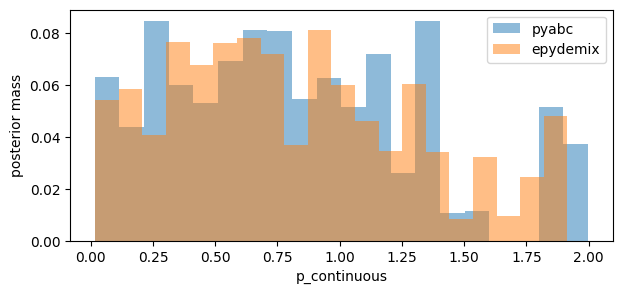

In [5]:
domain = np.arange(7)
observation = mixed_location_scale(
    {"p_discrete": 2, "p_continuous": 0.5, "rng": np.random.default_rng(47)}
)["data"]
prior = pyabc.Distribution(
    p_discrete=pyabc.RV("rv_discrete", values=(domain, np.full(7, 1 / 7))),
    p_continuous=pyabc.RV("uniform", 0, 2),
)
transition = pyabc.AggregatedTransition(
    mapping={
        "p_discrete": pyabc.DiscreteJumpTransition(domain=domain),
        "p_continuous": pyabc.MultivariateNormalTransition(),
    }
)
compare(
    mixed_location_scale,
    squared_distance,
    {"p_discrete": stats.randint(0, 7), "p_continuous": stats.uniform(0, 2)},
    prior,
    observation,
    [40.0, 25.0, 15.0],
    transition,
)